<a href="https://colab.research.google.com/github/officiallong/Fork-Test-Run/blob/master/ML_Coding_Assignment_Long_Nguyen.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Machine Learning Basics Coding Assignment**
Long Nguyen
BUS4 118S
Fall 2026

# **Part 1: House Price Prediction – Linear Regression**

In [8]:
# PART 1: HOUSE PRICE PREDICTION - LINEAR REGRESSION

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Data Source:
# Kaggle - House Sales Prediction (King County House Sales)
# https://www.kaggle.com/datasets/harlfoxem/housesalesprediction

# Load dataset
df = pd.read_csv('kc_house_data.csv.zip')

# Create a location column for the assignment
np.random.seed(42)
df['location'] = np.random.choice(
    ['Downtown', 'Suburb', 'Rural'],
    size=len(df)
)

# Keep the columns needed
df = df[['sqft_living', 'location', 'price']]

# Show dataset size and first 5 rows
print("Dataset Shape:", df.shape)
print(df.head())

# Features and target
X = df[['sqft_living', 'location']]
y = df['price']

# One-hot encode location
preprocessor = ColumnTransformer(
    transformers=[
        ('location',
         OneHotEncoder(sparse_output=False),
         ['location'])
    ],
    remainder='passthrough'
)

# Create pipeline
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Train model
model.fit(X_train, y_train)

# Predict price for a 2000 sq ft house in Downtown
new_house = pd.DataFrame({
    'sqft_living': [2000],
    'location': ['Downtown']
})

predicted_price = model.predict(new_house)

print(
    f"\nPredicted price for a 2000 sq ft house in Downtown: "
    f"${predicted_price[0]:,.2f}"
)

# Display model coefficients
location_features = (
    model.named_steps['preprocessor']
    .named_transformers_['location']
    .get_feature_names_out(['location'])
    .tolist()
)

feature_names = location_features + ['sqft_living']
coefficients = model.named_steps['regressor'].coef_

print("\nModel Coefficients:")
for feature, coef in zip(feature_names, coefficients):
    print(f"{feature}: {coef:,.2f}")

Dataset Shape: (21613, 3)
   sqft_living  location     price
0         1180     Rural  221900.0
1         2570  Downtown  538000.0
2          770     Rural  180000.0
3         1960     Rural  604000.0
4         1680  Downtown  510000.0

Predicted price for a 2000 sq ft house in Downtown: $510,963.14

Model Coefficients:
location_Downtown: -6,137.09
location_Rural: 2,517.49
location_Suburb: 3,619.60
sqft_living: 279.62


Interpretation:
The model predicts the price of a house using square footage and location. The square footage coefficient shows how the predicted price changes as square footage increases. The location coefficients show how the generated Downtown, Suburb, and Rural categories affect the model's prediction.

# **Part 2: Customer Churn Prediction – Logistic Regression**

In [9]:
# PART 2: CUSTOMER CHURN PREDICTION - LOGISTIC REGRESSION

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Data Source:
# Kaggle - Telco Customer Churn
# https://www.kaggle.com/datasets/blastchar/telco-customer-churn

# Load dataset
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Convert TotalCharges to numeric and remove missing values
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df = df.dropna()

# Convert Churn from Yes/No to 1/0
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Show dataset size
print("Dataset Shape:", df.shape)

# Features and target
X = df[
    [
        'tenure',
        'MonthlyCharges',
        'TotalCharges',
        'InternetService',
        'Contract',
        'TechSupport'
    ]
]

y = df['Churn']

# Numerical and categorical features
numerical_features = [
    'tenure',
    'MonthlyCharges',
    'TotalCharges'
]

categorical_features = [
    'InternetService',
    'Contract',
    'TechSupport'
]

# Scale numerical features and one-hot encode categorical features
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(
            handle_unknown='ignore',
            sparse_output=False
        ), categorical_features)
    ]
)

# Create pipeline
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        random_state=42,
        max_iter=1000
    ))
])

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Train model
model.fit(X_train, y_train)

# New customer
new_customer = pd.DataFrame({
    'tenure': [12],
    'MonthlyCharges': [75.00],
    'TotalCharges': [900.00],
    'InternetService': ['Fiber optic'],
    'Contract': ['Month-to-month'],
    'TechSupport': ['No']
})

# Predict churn probability
churn_probability = model.predict_proba(new_customer)[0][1]

# Classify using 0.5 threshold
threshold = 0.5
churn_prediction = 1 if churn_probability >= threshold else 0

print(f"\nChurn Probability: {churn_probability:.2%}")
print(f"Churn Prediction (1 = churn, 0 = no churn): {churn_prediction}")

Dataset Shape: (7032, 21)

Churn Probability: 61.32%
Churn Prediction (1 = churn, 0 = no churn): 1


Interpretation:
The model predicted a 61.32% probability that the customer will churn. Since 61.32% is above the 0.5 threshold, the customer is classified as likely to churn. A business could use this prediction to identify at-risk customers and offer discounts, better service, or other retention incentives.

# **Part 3: Customer Segmentation – K-Means**

Dataset Shape: (200, 5)


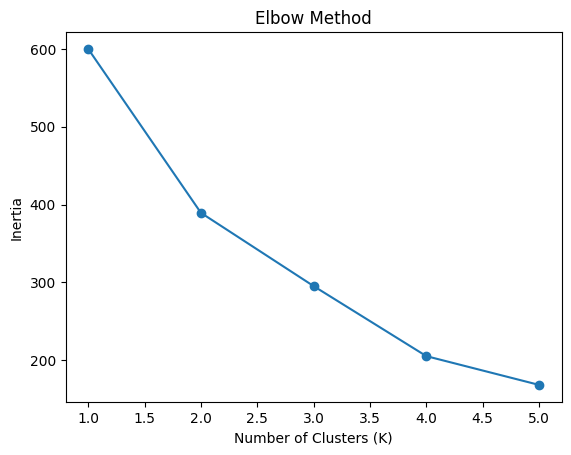


Cluster Averages:
               Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                       
0        25.838235           42.750000               53.647059
1        32.853659           87.341463               79.975610
2        51.274725           61.802198               34.208791

Customer segments saved to customer_segments.csv


In [10]:
# PART 3: CUSTOMER SEGMENTATION - K-MEANS

import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Data Source:
# Kaggle - Mall Customers Segmentation
# https://www.kaggle.com/datasets/abdallahwagih/mall-customers-segmentation

# Load dataset
df = pd.read_csv('Mall_Customers.csv')

# Show dataset size
print("Dataset Shape:", df.shape)

# Select features
features = [
    'Age',
    'Annual Income (k$)',
    'Spending Score (1-100)'
]

X = df[features]

# Scale numerical features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Elbow Method
inertia = []
K = range(1, 6)

for k in K:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Plot elbow graph
plt.plot(K, inertia, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

# Choose number of clusters
optimal_k = 3

# Run K-Means
kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

df['Cluster'] = kmeans.fit_predict(X_scaled)

# Analyze cluster averages
cluster_analysis = df.groupby('Cluster')[features].mean()

print("\nCluster Averages:")
print(cluster_analysis)

# Save results
df.to_csv('customer_segments.csv', index=False)

print("\nCustomer segments saved to customer_segments.csv")

Interpretation:
The elbow method was used to help choose the number of customer clusters.

Cluster 0 represents younger customers with moderate income and moderate spending. Marketing could focus on affordable promotions and product offers.

Cluster 1 represents high-income, high-spending customers. Marketing could focus on premium products, loyalty rewards, and exclusive offers.

Cluster 2 represents older customers with moderate income and lower spending. Marketing could use personalized promotions or discounts to encourage more purchases.